In [2]:
import pandas as pd
import numpy as np

In [3]:
data = pd.read_csv("D:\Semester 4 LPU\Machine Learning Project (Sem 4) with Multiple Version\heart-failure-prediction\heart.csv")

In [4]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [5]:
data.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [8]:
data['HeartDisease'].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

In [9]:
data['Sex'].unique()

<StringArray>
['M', 'F']
Length: 2, dtype: str

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [11]:
data["Sex"] = le.fit_transform(data["Sex"])

In [12]:
data

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,1,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,1,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,0,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [13]:
data['ChestPainType'].unique()

<StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str

In [14]:
data = pd.get_dummies(data, columns=['ChestPainType'], drop_first=True)

In [15]:
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,140,289,0,Normal,172,N,0.0,Up,0,True,False,False
1,49,0,160,180,0,Normal,156,N,1.0,Flat,1,False,True,False
2,37,1,130,283,0,ST,98,N,0.0,Up,0,True,False,False
3,48,0,138,214,0,Normal,108,Y,1.5,Flat,1,False,False,False
4,54,1,150,195,0,Normal,122,N,0.0,Up,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,Normal,132,N,1.2,Flat,1,False,False,True
914,68,1,144,193,1,Normal,141,N,3.4,Flat,1,False,False,False
915,57,1,130,131,0,Normal,115,Y,1.2,Flat,1,False,False,False
916,57,0,130,236,0,LVH,174,N,0.0,Flat,1,True,False,False


In [16]:
data['RestingECG'].unique()

<StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str

In [17]:
data = pd.get_dummies(data, columns=['RestingECG'], drop_first=True)

In [18]:
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,N,0.0,Up,0,True,False,False,True,False
1,49,0,160,180,0,156,N,1.0,Flat,1,False,True,False,True,False
2,37,1,130,283,0,98,N,0.0,Up,0,True,False,False,False,True
3,48,0,138,214,0,108,Y,1.5,Flat,1,False,False,False,True,False
4,54,1,150,195,0,122,N,0.0,Up,0,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,N,1.2,Flat,1,False,False,True,True,False
914,68,1,144,193,1,141,N,3.4,Flat,1,False,False,False,True,False
915,57,1,130,131,0,115,Y,1.2,Flat,1,False,False,False,True,False
916,57,0,130,236,0,174,N,0.0,Flat,1,True,False,False,False,False


In [19]:
data['ExerciseAngina'].unique()

<StringArray>
['N', 'Y']
Length: 2, dtype: str

In [20]:
data['ExerciseAngina'] = le.fit_transform(data['ExerciseAngina'])

In [21]:
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST
0,40,1,140,289,0,172,0,0.0,Up,0,True,False,False,True,False
1,49,0,160,180,0,156,0,1.0,Flat,1,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,Up,0,True,False,False,False,True
3,48,0,138,214,0,108,1,1.5,Flat,1,False,False,False,True,False
4,54,1,150,195,0,122,0,0.0,Up,0,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1.2,Flat,1,False,False,True,True,False
914,68,1,144,193,1,141,0,3.4,Flat,1,False,False,False,True,False
915,57,1,130,131,0,115,1,1.2,Flat,1,False,False,False,True,False
916,57,0,130,236,0,174,0,0.0,Flat,1,True,False,False,False,False


In [22]:
data['ST_Slope'].unique()

<StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str

In [23]:
data = pd.get_dummies(data, columns=['ST_Slope'], drop_first=True)

In [24]:
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1.2,1,False,False,True,True,False,True,False
914,68,1,144,193,1,141,0,3.4,1,False,False,False,True,False,True,False
915,57,1,130,131,0,115,1,1.2,1,False,False,False,True,False,True,False
916,57,0,130,236,0,174,0,0.0,1,True,False,False,False,False,True,False


In [25]:
data = data.astype(int)

In [26]:
data

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0,0,1,0,0,1,0,0,1
1,49,0,160,180,0,156,0,1,1,0,1,0,1,0,1,0
2,37,1,130,283,0,98,0,0,0,1,0,0,0,1,0,1
3,48,0,138,214,0,108,1,1,1,0,0,0,1,0,1,0
4,54,1,150,195,0,122,0,0,0,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1,1,0,0,1,1,0,1,0
914,68,1,144,193,1,141,0,3,1,0,0,0,1,0,1,0
915,57,1,130,131,0,115,1,1,1,0,0,0,1,0,1,0
916,57,0,130,236,0,174,0,0,1,1,0,0,0,0,1,0


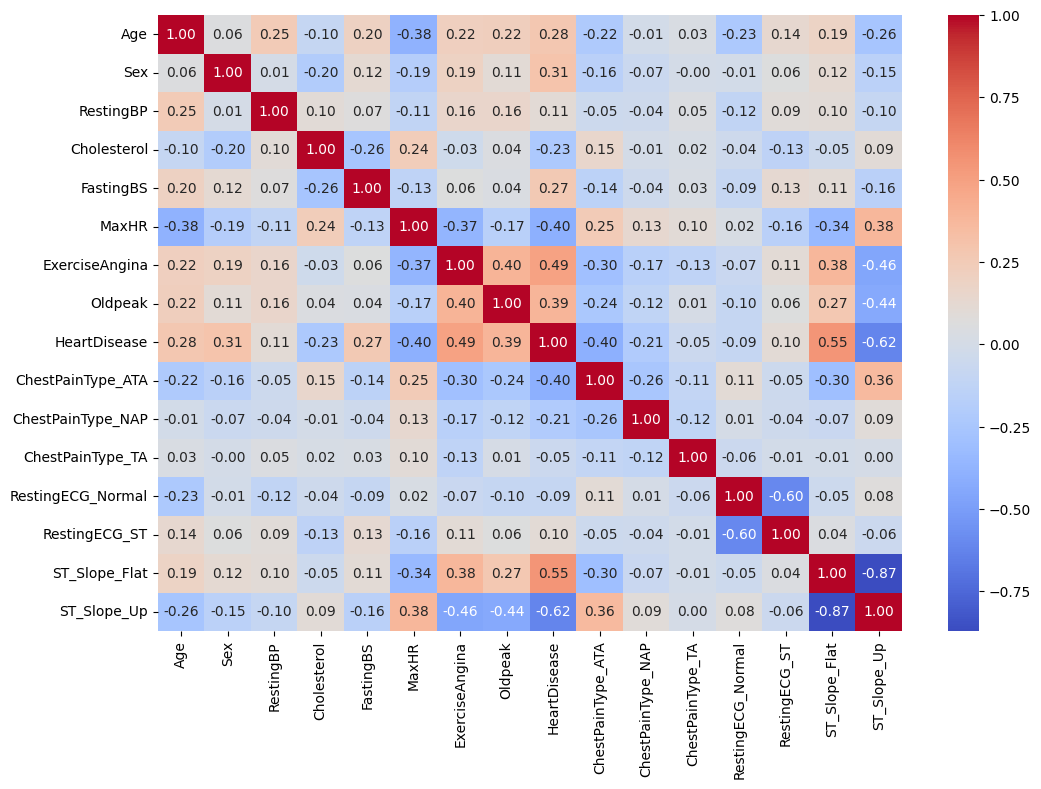

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
corr = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [29]:
data.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR',
       'ExerciseAngina', 'Oldpeak', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

# Remove the ChestPainType_TA Columns

In [30]:
data.drop(columns=['ChestPainType_TA'], inplace=True)

# ST_Slope_Up and ST_Slope_Flast having correlation 0.87.
# now the drop ST_Slope_Up.

In [31]:
data.drop(columns=['ST_Slope_Up'], inplace=True)

In [34]:
data.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat
0,40,1,140,289,0,172,0,0,0,1,0,1,0,0
1,49,0,160,180,0,156,0,1,1,0,1,1,0,1
2,37,1,130,283,0,98,0,0,0,1,0,0,1,0
3,48,0,138,214,0,108,1,1,1,0,0,1,0,1
4,54,1,150,195,0,122,0,0,0,0,1,1,0,0


In [ ]:
data.to_csv('Cleaned_Data.csv', index=False)